#### Какие шаги необходимо сделать?<br>
1) Загрузить предобработанные тексты (лемматизация, удаление знаков препинания)<br>
2) Обучить тематическую модель

## Подключение Google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Подключение библиотек

In [2]:
!pip install scipy==1.11.2
!pip install --upgrade gensim==3.8.2   # gensim нужной версии
!pip install pyLDAvis==3.4.1 # библиотека для визуализации

  Using cached gensim-3.8.2.tar.gz (23.4 MB)
  Preparing metadata (setup.py) ... done
  Created wheel for gensim: filename=gensim-3.8.2-cp312-cp312-linux_x86_64.whl size=23714511 sha256=1ccc5c8009ad730af55c1e2647cb0890e8e7ec33dc21f6899515586cc340756d
  Stored in directory: /root/.cache/pip/wheels/ff/b1/6c/420d81ba337aa9db566b2679e4de2bef31614d481b34124a6d
Successfully built gensim
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.7 MB/s eta 0:00:00


Основные пакеты, используемые в этой работе, – это gensim и pyLDAvis. Будут также использованы matplotlib, numpy и pandas для обработки и визуализации данных, которые необходимо импортировать. Кроме того, понадобится Mallet

In [3]:
import re
import numpy as np
import pandas as pd
from pprint import pprint #для красивого вывода списков

### Исправление ошибок. Из-за того, что Google Colab обновил python до 3.11, а код поддерживается в <= 3.10, нужно сделать правки в файлах.

Конкретно - ошибки с импортом некоторых функций из collections. Нужно заменить `from collections` на `from collections.abc`.

Будьте внимательны! Если из collections импортируется несколько функций/классов, нужно создать новую строку и импортировать функцию/класс с ошибкой в ней.

In [7]:
# Gensim
import gensim
import gensim.models
from gensim import corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim import models

In [8]:
# Работа с файлами и скачивание Mallet
import requests
import zipfile
import io
import os

In [9]:
# Plotting tools
import pyLDAvis
import pyLDAvis.gensim_models   # don't skip this
import matplotlib.pyplot as plt
%matplotlib inline

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# Enable logging for gensim - optional
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR) #Для красивого вывода справочной информации
import warnings
warnings.filterwarnings("ignore") #убираем предупреждения

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [11]:
# СКАЧИВАНИЕ MALLET

def download_zip(link, path):
    if not os.path.isdir(path):
        print(f'Download {path}... Please wait')
        r = requests.get(link)
        with r, zipfile.ZipFile(io.BytesIO(r.content)) as archive:
            archive.extractall('')
        print('Download complete!')


def download_mallet():
    download_zip('https://github.com/mimno/Mallet/releases/download/v202108/Mallet-202108-bin.zip', 'Mallet-202108')  # новая ссылка
    # download_zip("https://www.dropbox.com/s/1sfqnzesp0zz2kl/mallet-2.0.8.zip?dl=1", 'mallet-2.0.8')  старая ссылка


download_mallet()
mallet_path = 'Mallet-202108/bin/mallet'

Download Mallet-202108... Please wait
Download complete!


In [12]:
# Делаем файл с mallet исполняемым
!chmod 755 Mallet-202108/bin/mallet

##<b>1. ПРЕДОБРАБОТКА ДАННЫХ

In [13]:
folder_path = "/content/drive/MyDrive/SFU 3/Ex ml/2_морфологический_анализ_с_использованием_UDPipe/Lemma/Лемматизированные"

In [14]:
#чтение нескольких файлов
def read_texts_several(folder):
  if folder[-1] != '/':
      folder += '/'

  texts = []
  files = sorted(os.listdir(folder))
  for file in files:
    f = open(folder + file, 'r', encoding='utf8')
    text = f.read()
    f.close()
    texts.append(text)
  return texts, files

#разбитие текстов на слова и представление в виде списка
def texts_to_list(texts):
  result_list = []
  for text in texts:
    words = text.split(' ')
    result_list.append(words)
  return result_list

In [ ]:
texts, files = read_texts_several(folder_path)

print("Количество текстов:", len(texts))

Количество текстов: 98


In [15]:
class Bigram_mode():
  def __init__(self, min_count=None, threshold=None, delimiter=None):
    self.min_count = min_count
    self.threshold = threshold
    self.delimiter = delimiter


def create_bigrams(data_words, bigram_mode):
  bigram_mod = gensim.models.phrases.Phraser(bigram)
  bigram = gensim.models.Phrases(data_words,
                                 min_count=bigram_mode.min_count,
                                 threshold=bigram_mode.threshold,
                                 delimiter = bigram_mode.delimiter)
  return [bigram_mod[text] for text in texts]

In [16]:
def preprocess(texts, make_bigrams, bigram_mode):
  data_words = texts_to_list(texts)
  if make_bigrams:
    data_words = create_bigrams(data_words, bigram_mode)

  id2word = corpora.Dictionary(data_words)
  corpus = [id2word.doc2bow(text) for text in data_words]

  return data_words, id2word, corpus

def read_preprocess_several(
                        folder,
                        make_bigrams=False,
                        min_count=None,
                        threshold=None,
                        delimiter=None
):
  texts, files = read_texts_several(folder)
  bigram_mode = Bigram_mode(min_count, threshold, delimiter)
  return preprocess(texts, make_bigrams, bigram_mode) + (files, )

In [17]:
path_to_models = '/content/drive/MyDrive/mydata/models/topic_models/'
os.makedirs(path_to_models, exist_ok=True)

## Предобработка текстов в одном файле

<li>file_name - имя исходного файла</li>
<li>path_to_file - путь к исходному файлу (по умолчанию: drive/My Drive/mydata/)</li>
<li>delim - разделитель между текстами (по умолчанию: \n)</li>
<li>make_bigrams - создавать или не создавать биграммы</li>

Если make_bigrams = True, то нужно задать следующие параметры:

<li>min_count - игнорировать все слова и биграммы с общим количеством собранных данных ниже этого значения.</li>
<li>threshold - представляет собой порог оценки для формирования фраз (чем выше, тем меньше фраз будет в итоге). Фраза из слов a, за которой следует b, принимается, если оценка фразы больше порогового значения. Сильно зависит от конкретной функции подсчета оценки.</li>
<li>delimiter – разделитель (по умолчанию "+")</li>

In [ ]:
texts, id2word, corpus, file_names = read_preprocess_one(
        file_name = 'M&M_Lemma.txt',
        path_to_file = '/content/drive/MyDrive/mydata/M&M/',
        delim = '\n',
        make_bigrams = False,
        min_count = 5,
        threshold = 100,
        delimiter = b'+'
)

## Предобработка текстов в разных файлах

<li>folder - путь к папке с файлами </li>
<li>delim - разделитель между текстами (по умолчанию: \n)</li>
<li>make_bigrams - создавать или не создавать биграммы</li>

Если make_bigrams = True, то нужно задать следующие параметры:

<li>min_count - игнорировать все слова и биграммы с общим количеством собранных данных ниже этого значения.</li>
<li>threshold - представляет собой порог оценки для формирования фраз (чем выше, тем меньше фраз будет в итоге). Фраза из слов a, за которой следует b, принимается, если оценка фразы больше порогового значения. Сильно зависит от конкретной функции подсчета оценки.</li>
<li>delimiter – разделитель (по умлочанию "+")</li>

In [18]:
texts, id2word, corpus, file_names = read_preprocess_several(
        folder = "/content/drive/MyDrive/SFU 3/Ex ml/2_морфологический_анализ_с_использованием_UDPipe/Lemma/Лемматизированные",
        make_bigrams = False,
        min_count = 5,
        threshold = 100,
        delimiter = b'+'
)

## Создание структуры

In [19]:
class Corpus():
  def __init__(self, dictionary, corpus, texts):
    self.dictionary = dictionary
    if type(self.dictionary) == tuple:
      self.dictionary = self.dictionary[0]
    self.corpus = corpus
    if type(self.corpus) == tuple:
      self.dictionary = self.corpus[0]
    self.texts = texts


text_corpus = Corpus(
    dictionary=id2word,
    corpus=corpus,
    texts=texts
)

##<b>2. Построение тематической модели

https://radimrehurek.com/gensim/models/ldamodel.html

## Количественные оценки качества модели

а) **Перплексия** — известная в вычислительной лингвистике мера качества модели языка. В данном случае моделью языка является условное распределение слов в документах.<br>

*Перплексия* — это мера несоответсвия или "удивленности" модели термам, встречающимся в документах.<br>

*Перплексия* ничего не говорит об интерпретируемости тем, а только говорит о том, насколько хорошо построилось матричное разложение. То есть ничего не говорит о том, насколько построенная модель будет полезна
для конечных приложений. Поэтому были придуманы меры качества, которые измеряют, насколько темы
хороши и понятны. Такую оценку можно сделать только при помощи экспертов.<br>

Чем **МЕНЬШЕ**, тем **ЛУЧШЕ**
<br><br>
б) В ходе экспериментов было выявлено, что экспертные оценки хорошо коррелируют с такой мерой качества как **когерентность**, которая может быть вычислена полностью автоматически без участия человека. **Когерентность темы** — мера, которая показывает, насколько слова, встречающиеся рядом в текстах, оказываются в топах одних и тех же тем.<br>

Чем **БОЛЬШЕ**, тем **ЛУЧШЕ**

In [20]:
def get_perplexity(lda_model, corpus):
  perplexity = lda_model.log_perplexity(corpus)
  return 2**(-perplexity)


def get_coherence(lda_model, text_corpus):
  coherence_model_lda = CoherenceModel(model=lda_model, texts=text_corpus.texts, dictionary=text_corpus.dictionary, coherence='c_v')
  return coherence_model_lda.get_coherence()


def estimate_modelLDA(lda_model, text_corpus):
  perplexity_lda = get_perplexity(lda_model, text_corpus.corpus)
  coherence_lda = get_coherence(lda_model, text_corpus)
  print('Perplexity:', perplexity_lda)
  print('Coherence score: ', coherence_lda)

### Параметры модели Mallet:
https://radimrehurek.com/gensim/models/wrappers/ldamallet.html

<li><b>mallet_path</b> - путь к бинарному файлу маллета</li>
<li><b>corpus</b> - сам корпус</li>
<li><b>id2word</b> - словарь соответсвия id и words</li>
<li><b>num_topics</b> - число тем</li>
<li><b>iterations</b> - число проходов по корпусу в течение обучения</li>



##<b>а) Самостоятельный выбор модели</b>

In [75]:
lda_model = gensim.models.wrappers.LdaMallet(
                    mallet_path=mallet_path,
                    corpus=corpus,
                    id2word=id2word,
                    num_topics=11,
                    iterations=500
)

lda_model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(lda_model) #преобразование к gensim

# Сохранение модели
lda_model.save(path_to_models + "mallet_model1")

In [76]:
lda_model = gensim.models.LdaModel.load(path_to_models + "mallet_model1")
estimate_modelLDA(lda_model, text_corpus)

Perplexity: nan
Coherence score:  0.278355656300945


## <b>Визуализация модели

In [34]:
def visualize_terms_topics(lda_model, text_corpus):
  pyLDAvis.enable_notebook()
  return pyLDAvis.gensim_models.prepare(lda_model, text_corpus.corpus, text_corpus.dictionary)


def visualize_docs_topics(lda_model, text_corpus, figsize=(20,6)):
    ids = file_names
    if ids is None:
        ids = list(range(len(text_corpus.texts)))
    res_dict = {'topics': [], 'file_names': [], 'scores': []}
    for text_id, item in enumerate(text_corpus.corpus):
        topic_dist = lda_model.get_document_topics(item)
        topics, scores = tuple(zip(*topic_dist))
        res_dict['topics'].extend(topics)
        res_dict['file_names'].extend([ids[text_id]]*len(topics))
        res_dict['scores'].extend(scores)
    res_df = pd.DataFrame().from_dict(res_dict)
    res_df['topics'] = res_df['topics'].apply(lambda x: x+1)
    ax = res_df.pivot(index='file_names', columns='topics', values='scores').plot.bar(figsize=(20,6))

In [55]:
visualize_terms_topics(lda_model, text_corpus)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5     -0.003396  0.109887       1        1  14.467533
4     -0.266512 -0.155557       2        1  13.622123
1      0.122495  0.166558       3        1  13.175778
0      0.012145 -0.007163       4        1  12.799174
6      0.218609  0.089187       5        1  11.979459
2     -0.245404  0.137580       6        1  11.754447
7      0.026190  0.007938       7        1  11.423541
3      0.135873 -0.348430       8        1  10.777945, topic_info=          Term        Freq       Total Category  logprob  loglift
94    говорить  360.000000  360.000000  Default  30.0000  30.0000
584    человек  276.000000  276.000000  Default  29.0000  29.0000
528      такой  241.000000  241.000000  Default  28.0000  28.0000
796      рубль  101.000000  101.000000  Default  27.0000  27.0000
622        ваш  185.000000  185.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
1572       дом   29.886044  100.027379   Topic8  -5.3731   1.0196
115       дать   31.878447  156.248825   Topic8  -5.3086   0.6381
322       один   33.870850  274.940327   Topic8  -5.2480   0.1337
579    хороший   27.893641   84.283996   Topic8  -5.4421   1.1219
47        весь   27.893641  440.865234   Topic8  -5.4421  -0.5327

[688 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
0         7  0.992928  актриса
1         7  0.992928  актёрка
3         7  0.992928   алтарь
4         6  0.343819   андрей
4         7  0.649436   андрей
...     ...       ...      ...
601       6  0.088091      это
601       7  0.240557      это
601       8  0.157548      это
2374      3  0.189393        я
2374      8  0.811685        я

[849 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 5, 2, 1, 7, 3, 8, 4])

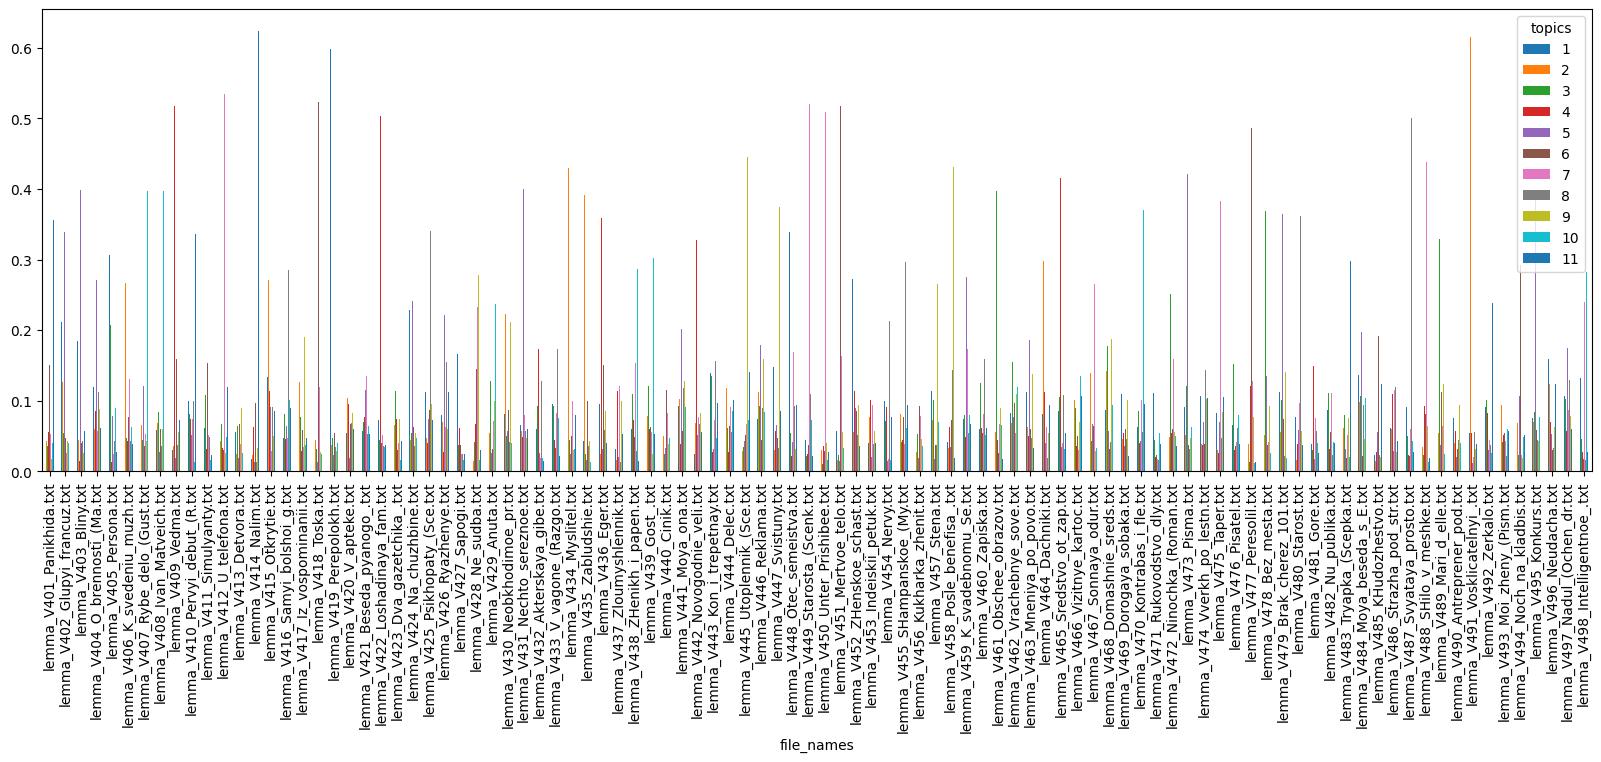

In [63]:
visualize_docs_topics(lda_model, text_corpus, figsize=(20,6))

##<b>б) Автоматический выбор модели</b>

In [37]:
class Fine_tuning():
  def __init__(self, start, limit, step):
    self.start = start
    self.limit = limit
    self.step = step


class LDAParams():
  def __init__(self, num_topics, iterations):
    self.num_topics = num_topics
    self.iterations = iterations


  def print(self):
    print('num_topics:', self.num_topics)
    print('iterations:', self.iterations)


class Model_opt():
  def __init__(self):
    self.model = None
    self.params = None
    self.perplexity = 1e30
    self.coherence = 0


class Models_opt_list():
  def __init__(self):
    self.models_list = []
    self.params_list = []
    self.perplexity_list = []
    self.coherence_list = []

In [38]:
#список Model_opt -> Models_opt_list
def transform_to_list(models_opt):
  models_opt_list = Models_opt_list()
  for model_opt in models_opt:
    models_opt_list.models_list.append(model_opt.model)
    models_opt_list.params_list.append(model_opt.params)
    models_opt_list.perplexity_list.append(model_opt.perplexity)
    models_opt_list.coherence_list.append(model_opt.coherence)

  return models_opt_list


#Функция перебора числа тем и подсчета метрик
def compute_estimate_values(text_corpus, fine_tuning_topics, fine_tuning_iterations):

    models_opt_by_perp = []
    models_opt_by_coh = []
    for num_topics in range(fine_tuning_topics.start, fine_tuning_topics.limit+1, fine_tuning_topics.step):
      print('processing num_topics:', num_topics)
    #   best_model_opt_perp = Model_opt()
      best_model_opt_coh = Model_opt()
      for iterations in range(fine_tuning_iterations.start, fine_tuning_iterations.limit+1, fine_tuning_iterations.step):

          #создаем модель и добавляем в список
          model = gensim.models.wrappers.LdaMallet(
                      mallet_path=mallet_path,
                      corpus=text_corpus.corpus,
                      id2word=text_corpus.dictionary,
                      num_topics=num_topics,
                      iterations=iterations
          )

          model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(model)

          cur_coherence = get_coherence(model, text_corpus)
        #   cur_perplexity = get_perplexity(model, text_corpus.corpus)

          #обновление модели по когерентности
          if cur_coherence > best_model_opt_coh.coherence:
            best_model_opt_coh.coherence = cur_coherence
            # best_model_opt_coh.perplexity = cur_perplexity
            best_model_opt_coh.model = model
            best_model_opt_coh.params = LDAParams(num_topics, iterations)

        #   #обновление модели по перплексии
        #   if cur_perplexity < best_model_opt_perp.perplexity:
        #     best_model_opt_perp.coherence = cur_coherence
        #     best_model_opt_perp.perplexity = cur_perplexity
        #     best_model_opt_perp.model = model
        #     best_model_opt_perp.params = LDAParams(num_topics, iterations)


    #   models_opt_by_perp.append(best_model_opt_perp)
      models_opt_by_coh.append(best_model_opt_coh)

    # models_opt_list_perp = transform_to_list(models_opt_by_perp)
    models_opt_list_coh = transform_to_list(models_opt_by_coh)

    return models_opt_list_coh


#функция для визуализации метрик
def visualize_est(est_values, est_text, fine_tuning_topics):
  x = range(fine_tuning_topics.start, fine_tuning_topics.limit+1, fine_tuning_topics.step)
  plt.plot(x, est_values)
  plt.xlabel("Num Topics")
  plt.ylabel(est_text +" score")
  plt.legend((est_text+"_values"), loc='best')
  plt.show()


def get_ind_byTopicNum(topic_num, fine_tuning_topics):
  return (topic_num - fine_tuning_topics.start) // fine_tuning_topics.step


print('количество текстов:', len(texts))

количество текстов: 98


In [39]:
fine_tuning_topics = Fine_tuning(
    start = 8,
    limit = 10,
    step = 1
)

fine_tuning_iterations = Fine_tuning(
    start = 1000,
    limit = 1000,
    step = 50
)

## Вызов функции для оптимизации. Параметры:

<li>text_corpus - структура корпуса</li>
<li>fine_tuning_topics - параметры для оптимизации числа тем</li>
<li>fine_tuning_passes - параметры для оптимизации числа проходов (passes)</li>
<li>fine_tuning_chunksize - параметры для оптимизации chunksize</li>

In [40]:
#Может занять очень много времени
models_opt_list_coh = compute_estimate_values(
    text_corpus = text_corpus,
    fine_tuning_topics = fine_tuning_topics,
    fine_tuning_iterations = fine_tuning_iterations
)

processing num_topics: 8
processing num_topics: 9
processing num_topics: 10


## Анализ графиков оптимизации по перплексии

In [ ]:
#visualize_est(models_opt_list_perp.perplexity_list, 'perplexity', fine_tuning_topics)

In [ ]:
# visualize_est(models_opt_list_perp.coherence_list, 'coherence', fine_tuning_topics)

## Анализ графиков оптимизации по когерентности

In [ ]:
# visualize_est(models_opt_list_coh.perplexity_list, 'perplexity', fine_tuning_topics)

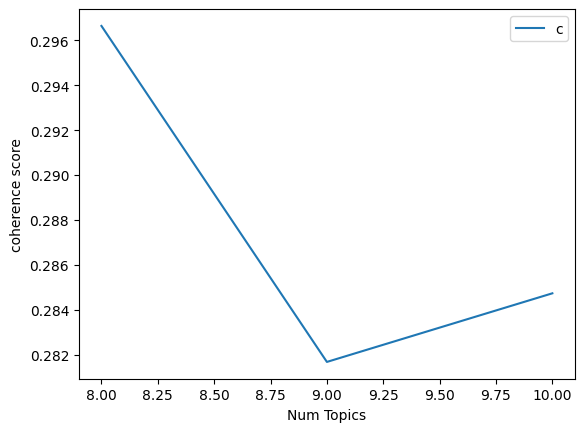

In [64]:
visualize_est(models_opt_list_coh.coherence_list, 'coherence', fine_tuning_topics)

In [67]:
topic_num = 8
models_opt_chosen = models_opt_list_coh

In [68]:
ind = get_ind_byTopicNum(topic_num, fine_tuning_topics)
params = models_opt_chosen.params_list[ind]
params.print()

num_topics: 8
iterations: 1000


In [45]:
model = models_opt_chosen.models_list[ind]
model.save(path_to_models + 'optimal_mallet_model5')

In [46]:
lda_model = gensim.models.LdaModel.load(path_to_models + "optimal_mallet_model5")
estimate_modelLDA(lda_model, text_corpus)

Perplexity: nan
Coherence score:  0.29664466161706804


## Визуализация тем и ключевых слов

###Что означает вывод pyLDAvis?

Каждый пузырь на левом графике представляет тему. Чем больше пузырь, тем больше распространена эта тема.

Хорошая тематическая модель будет иметь довольно большие непересекающиеся пузыри, разбросанные по всей диаграмме, а не сгруппированные в одном квадранте.

Модель со слишком большим количеством тем, как правило, имеет много перекрытий, пузырьки небольшого размера, сгруппированные в одной области диаграммы.

Если вы наведете курсор на один из пузырей и справа обновятся полосы графиков. Эти слова являются ключевыми словами, они формируют выбранную тему.

В итоге мы успешно создали красивую тематическую модель.

## <b>3. Визуализация модели

In [47]:
visualize_terms_topics(lda_model, text_corpus)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5     -0.003396  0.109887       1        1  14.467531
4     -0.266512 -0.155557       2        1  13.622125
1      0.122495  0.166558       3        1  13.175776
0      0.012145 -0.007163       4        1  12.799172
6      0.218609  0.089187       5        1  11.979459
2     -0.245404  0.137580       6        1  11.754451
7      0.026190  0.007938       7        1  11.423546
3      0.135873 -0.348430       8        1  10.777942, topic_info=          Term        Freq       Total Category  logprob  loglift
94    говорить  360.000000  360.000000  Default  30.0000  30.0000
584    человек  276.000000  276.000000  Default  29.0000  29.0000
528      такой  241.000000  241.000000  Default  28.0000  28.0000
796      рубль  101.000000  101.000000  Default  27.0000  27.0000
622        ваш  185.000000  185.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
1572       дом   29.886035  100.027377   Topic8  -5.3731   1.0196
115       дать   31.878438  156.248825   Topic8  -5.3086   0.6381
322       один   33.870840  274.940315   Topic8  -5.2480   0.1337
579    хороший   27.893633   84.283980   Topic8  -5.4421   1.1219
47        весь   27.893633  440.865182   Topic8  -5.4421  -0.5327

[696 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
0         7  0.992928  актриса
1         7  0.992928  актёрка
3         7  0.992928   алтарь
4         6  0.343819   андрей
4         7  0.649436   андрей
...     ...       ...      ...
601       6  0.088091      это
601       7  0.240557      это
601       8  0.157548      это
2374      3  0.189393        я
2374      8  0.811685        я

[857 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 5, 2, 1, 7, 3, 8, 4])

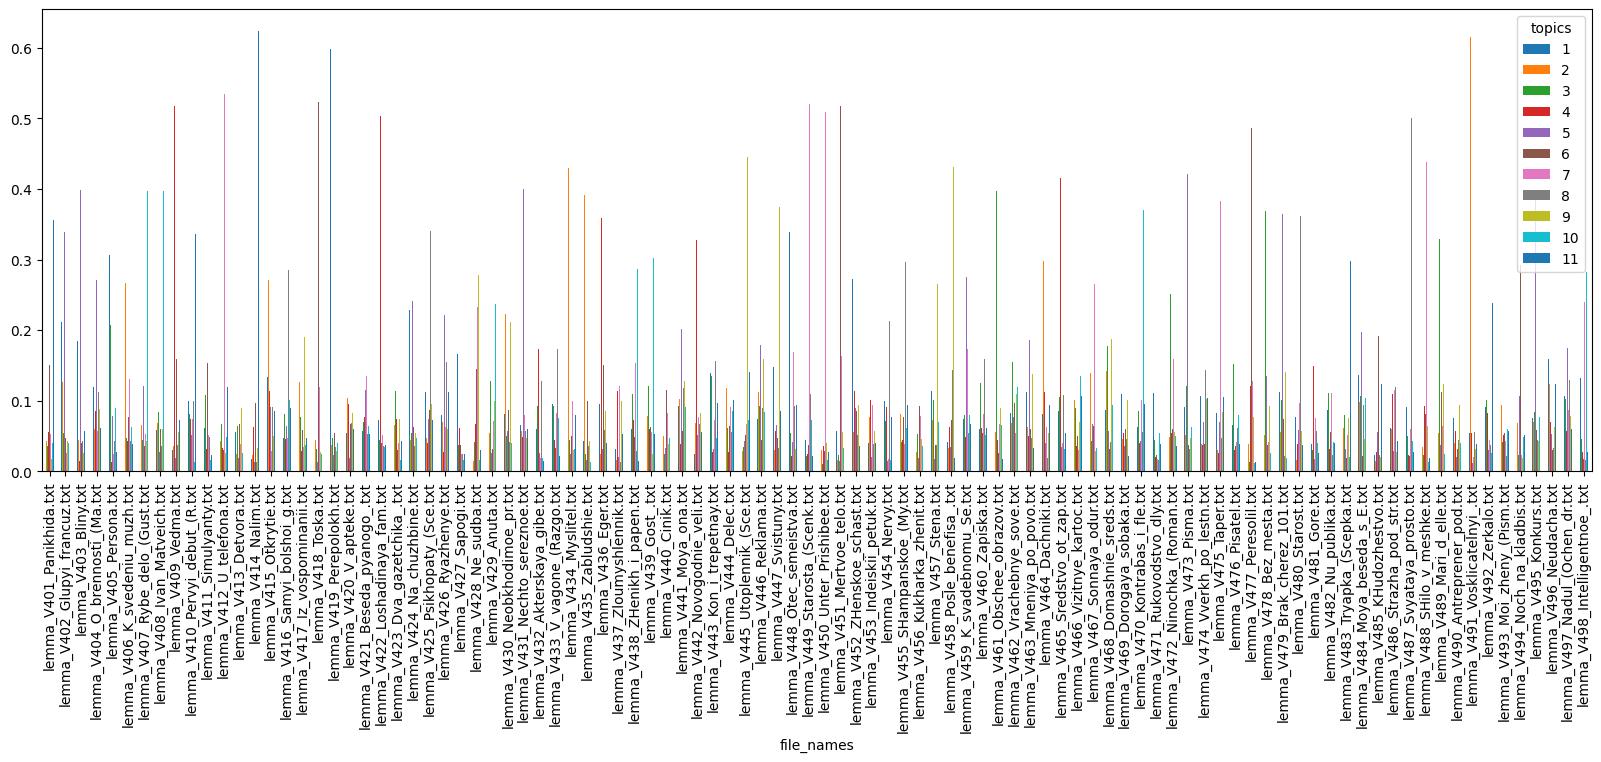

In [69]:
visualize_docs_topics(lda_model, text_corpus, figsize=(20,6))

## 4. Сохранение разбиения на темы

In [49]:
def get_topic_document_df(lda_model, file_names):
    def align_topics(topic_dist):
        topics, scores = tuple(zip(*topic_dist))
        res_topics = list(range(lda_model.num_topics))
        res_scores = [0.0 for _ in range(len(res_topics))]
        for topic, score in zip(topics, scores):
            res_scores[topic] = score
        return res_topics, res_scores

    res_dict = {'topics': [], 'file_names': [], 'scores': []}
    all_topics_to_zero = list(range(lda_model.num_topics))
    for text_id, item in enumerate(text_corpus.corpus):
        topic_dist = lda_model.get_document_topics(item)
        topics, scores = align_topics(topic_dist)
        res_dict['topics'].extend(topics)
        res_dict['file_names'].extend([file_names[text_id]]*len(topics))
        res_dict['scores'].extend(scores)
    res_df = pd.DataFrame().from_dict(res_dict)
    res_df['scores'] = res_df['scores'].apply(lambda score: round(score, 8))
    return res_df


def get_topic_terms_dict(lda_model, text_corpus, words_in_topic):
    res_dict = {}
    for topic_id in range(lda_model.num_topics):
        word_ids, _ = tuple(zip(*lda_model.get_topic_terms(topic_id, words_in_topic)))
        words = [text_corpus.dictionary[word_id] for word_id in word_ids]
        res_dict[topic_id] = words
    return res_dict


def save_topics_in_docs(topic_document_df, fname_to_id, path_to_save):
    res_lst = ['docId,filename,toptopics...']
    grouped_df = topic_document_df.groupby('file_names')
    for file_name in grouped_df.groups:
        doc_df = grouped_df.get_group(file_name).sort_values('scores', ascending=False)
        doc_info = [str(fname_to_id[file_name]), file_name]
        for topic, score in zip(doc_df['topics'], doc_df['scores']):
            doc_info.append(f'{topic},{score}')
        res_lst.append(','.join(doc_info))
    file_path = os.path.join(path_to_save, 'topics-in-docs.csv')
    with open(file_path, 'w', encoding='utf8') as f:
        f.write('\n'.join(res_lst) + '\n')


# def save_docs_in_topics(topic_document_df, path_to_save):
#     res_dict = {'topicId': [], 'rank': [], 'docId': [], 'filename':[]}
#     grouped_df = topic_document_df.groupby('topics')
#     for topic in grouped_df.groups:
#         doc_df = grouped_df.get_group(topic).sort_values('doc_ids', ascending=True)
#         doc_df['doc_ids'] = doc_df['file_name'].apply(lambda fname: fname_to_id[fname])
#         doc_df = doc_df.sort_values('doc_ids', ascending=True)
#         res_dict[topic_to_repr[topic]] = doc_df['scores']

#     file_path = os.path.join(path_to_save, 'docs-in-topics.csv')
#     pd.DataFrame().from_dict(res_dict).to_csv(file_path, index=False, encoding='utf8')


def save_topics_meta(topic_document_df, topic_to_terms, fname_to_id, words_in_doc_topic, path_to_save):
    topic_to_repr = {topic: f'{topic} ' + ' '.join(terms[:words_in_doc_topic]) for topic, terms in topic_to_terms.items()}
    res_dict = {}
    res_dict['docId'] = list(fname_to_id.values())
    res_dict['filename'] = list(fname_to_id.keys())
    grouped_df = topic_document_df.groupby('topics')
    for topic in grouped_df.groups:
        doc_df = grouped_df.get_group(topic)
        doc_df['doc_ids'] = doc_df['file_names'].apply(lambda fname: fname_to_id[fname])
        doc_df = doc_df.sort_values('doc_ids', ascending=True)
        res_dict[topic_to_repr[topic]] = list(doc_df['scores'])

    file_path = os.path.join(path_to_save, 'topics-metadata.csv')
    pd.DataFrame().from_dict(res_dict).to_csv(file_path, index=False, encoding='utf8')


def save_topics_words(topic_to_terms, path_to_save):
    res_dict = {'Topic Id': [], 'Top Words...': []}
    for topic, words in topic_to_terms.items():
        res_dict['Topic Id'].append(topic)
        res_dict['Top Words...'].append(' '.join(words))
    file_path = os.path.join(path_to_save, 'topic-words.csv')
    pd.DataFrame().from_dict(res_dict).to_csv(file_path, index=False, encoding='utf8')


def save_topics(lda_model, text_corpus, save_config):
    if file_names is None:
        print('Данные были загружены из одного файла, невозможно сохранить')
        return
    os.makedirs(save_config['path_to_folder'], exist_ok=True)
    fname_to_id = {fname: i for i, fname in enumerate(file_names)}
    topic_document_df = get_topic_document_df(lda_model, file_names)
    topic_to_terms = get_topic_terms_dict(lda_model, text_corpus,
                                          save_config['words_in_topic'])
    save_topics_in_docs(topic_document_df, fname_to_id, save_config['path_to_folder'])
    # save_docs_in_topics(topic_document_df)
    save_topics_meta(topic_document_df, topic_to_terms, fname_to_id,
                     save_config['words_in_doc_topic'], save_config['path_to_folder'])
    save_topics_words(topic_to_terms, save_config['path_to_folder'])

In [50]:
save_config = {
    'path_to_folder': '/content/drive/MyDrive/mydata/topic_models/M&M', # путь к папке для сохранения, создается автоматически
    'topics_in_docs': 3, # сколько сохранять главных тем для каждого документа
    'words_in_topic': 20,
    'words_in_doc_topic': 5,
}

save_topics(
    lda_model=lda_model,
    text_corpus=text_corpus,  # исходная информация о текстах
    save_config=save_config
)